# Init

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('/home/pedrorozin/scripts/python')
import importlib
import torch
from scipy.integrate import simpson, solve_ivp
import delta_solver_mg_pedro
#reload para actualizar el módulo si se hacen cambios
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver

In [3]:
#usar cpu
device = torch.device('cpu')
print('Using device:', device)

Using device: cpu


# Deltas

In [4]:
import funciones_tesis as ft
import importlib
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
h=0.68 
mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 1000)/h  # k en 1/Mpc
solver = VectorizedDeltaSolver(k_array=mis_ks, h=h, Om_m_0=0.3, b=0.001) #inicializo solver con los parámetros que quiero usar para el ejemplo (pueden ser otros, pero deben ser consistentes con los datos de entrenamiento de la red)

VectorizedDeltaSolver usando: cuda


## Soluciones

Solución numérica a la ec. de perturbaciones en MG y $\Lambda$ CDM con el solver y la red. **NO** correr todo de golpe porque hay celdas para computar las soluciones y celdas para cargar variables ya computadas.

### Correr esto para generar y guardar soluciones (GUARDA. NO CORRER POR ERROR)

In [ ]:
h = .68
b= .001
a_ini =0.03
z_ini = 1/a_ini - 1
mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 100)/h  # k en 1/Mpc
solver = VectorizedDeltaSolver(k_array=mis_ks, h=h, Om_m_0=0.3, b=b, z_0=z_ini)
a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel()
a_LCDM, delta_LCDM, delta_p_LCDM = solver.solve_delta_lcdm_vectorized_parallel()
z_mg = 1/a_mg - 1

VectorizedDeltaSolver usando: cuda
Resolviendo 15 valores de k en paralelo con 16 procesos...


Resolución paralela completada.
Resolviendo LCDM para 15 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.


In [ ]:
#guardar todos estos arrays de la manera mas eficiente para importarlos luego
path = '/home/pedrorozin/scripts/outputs_pedro/modified_gravity'
file_name = 'delta_mg_vs_k_and_z2.npz'
# np.savez_compressed(path + f'/{file_name}', mis_ks=mis_ks, a_mg=a_mg, delta_mg=delta_mg, delta_p_mg=delta_p_mg,
# 					a_LCDM=a_LCDM, delta_LCDM=delta_LCDM, delta_p_LCDM=delta_p_LCDM, z_mg=z_mg)

# #guardar info en un txt
# with open(path + f'/{file_name}_info.txt', 'w') as f:
# 	f.write('Arrays guardados:\n')
# 	f.write('mis_ks: array de k en 1/Mpc\n')
# 	f.write('a_mg: array de a para MG\n')
# 	f.write('delta_mg: array de delta para MG\n')
# 	f.write('delta_p_mg: array de d(delta)/da para MG\n')
# 	f.write('a_LCDM: array de a para LCDM\n')
# 	f.write('delta_LCDM: array de delta para LCDM\n')
# 	f.write('delta_p_LCDM: array de d(delta)/da para LCDM\n')
# 	f.write('z_mg: array de z correspondiente a a_mg\n')
# 	f.write('\nDimensiones:\n')
# 	f.write(f'mis_ks: {mis_ks.shape}\n')
# 	f.write(f'a_mg: {a_mg.shape}\n')
# 	f.write(f'delta_mg: {delta_mg.shape}\n')
# 	f.write(f'delta_p_mg: {delta_p_mg.shape}\n')
# 	f.write(f'a_LCDM: {a_LCDM.shape}\n')
# 	f.write(f'delta_LCDM: {delta_LCDM.shape}\n')
# 	f.write(f'delta_p_LCDM: {delta_p_LCDM.shape}\n')
# 	f.write(f'z_mg: {z_mg.shape}\n')
# 	f.write(f'\nParametros usados:\n')
# 	f.write(f'h: {solver.h}\n')
# 	f.write(f'Om_m_0: {solver.Om_m_0}\n')
# 	f.write(f'b: {solver.b}\n')
# print(f"Arrays guardados en {path + f'/{file_name}'} y {path + f'/{file_name}_info.txt'}")

Arrays guardados en /home/pedrorozin/scripts/outputs_pedro/modified_gravity/delta_mg_vs_k_and_z2.npz y /home/pedrorozin/scripts/outputs_pedro/modified_gravity/delta_mg_vs_k_and_z2.npz_info.txt


### Correr para cargar soluciones guardadas

In [6]:
#load the arrays
path = '/home/pedrorozin/scripts/outputs_pedro/modified_gravity'
data = np.load(path + '/delta_mg_vs_k_and_z2.npz')
mis_ks = data['mis_ks']
a_mg = data['a_mg']
delta_mg = data['delta_mg']
delta_p_mg = data['delta_p_mg']
a_LCDM = data['a_LCDM']
delta_LCDM = data['delta_LCDM']
delta_p_LCDM = data['delta_p_LCDM']
z_mg = data['z_mg']

# print shapes
print(f"mis_ks: {mis_ks.shape}")
print(f"a_mg: {a_mg.shape}")
print(f"delta_mg: {delta_mg.shape}")
print(f"delta_p_mg: {delta_p_mg.shape}")
print(f"a_LCDM: {a_LCDM.shape}")
print(f"delta_LCDM: {delta_LCDM.shape}")
print(f"delta_p_LCDM: {delta_p_LCDM.shape}")
print(f"z_mg: {z_mg.shape}")
##print z ini
print(f"z_mg ini: {z_mg[0]:.2f}, z_mg fin: {z_mg[-1]:.2f}")

mis_ks: (1000,)
a_mg: (1000,)
delta_mg: (1000, 1000)
delta_p_mg: (1000, 1000)
a_LCDM: (1000,)
delta_LCDM: (1000, 1000)
delta_p_LCDM: (1000, 1000)
z_mg: (1000,)
z_mg ini: 30.00, z_mg fin: 0.00


### Plots

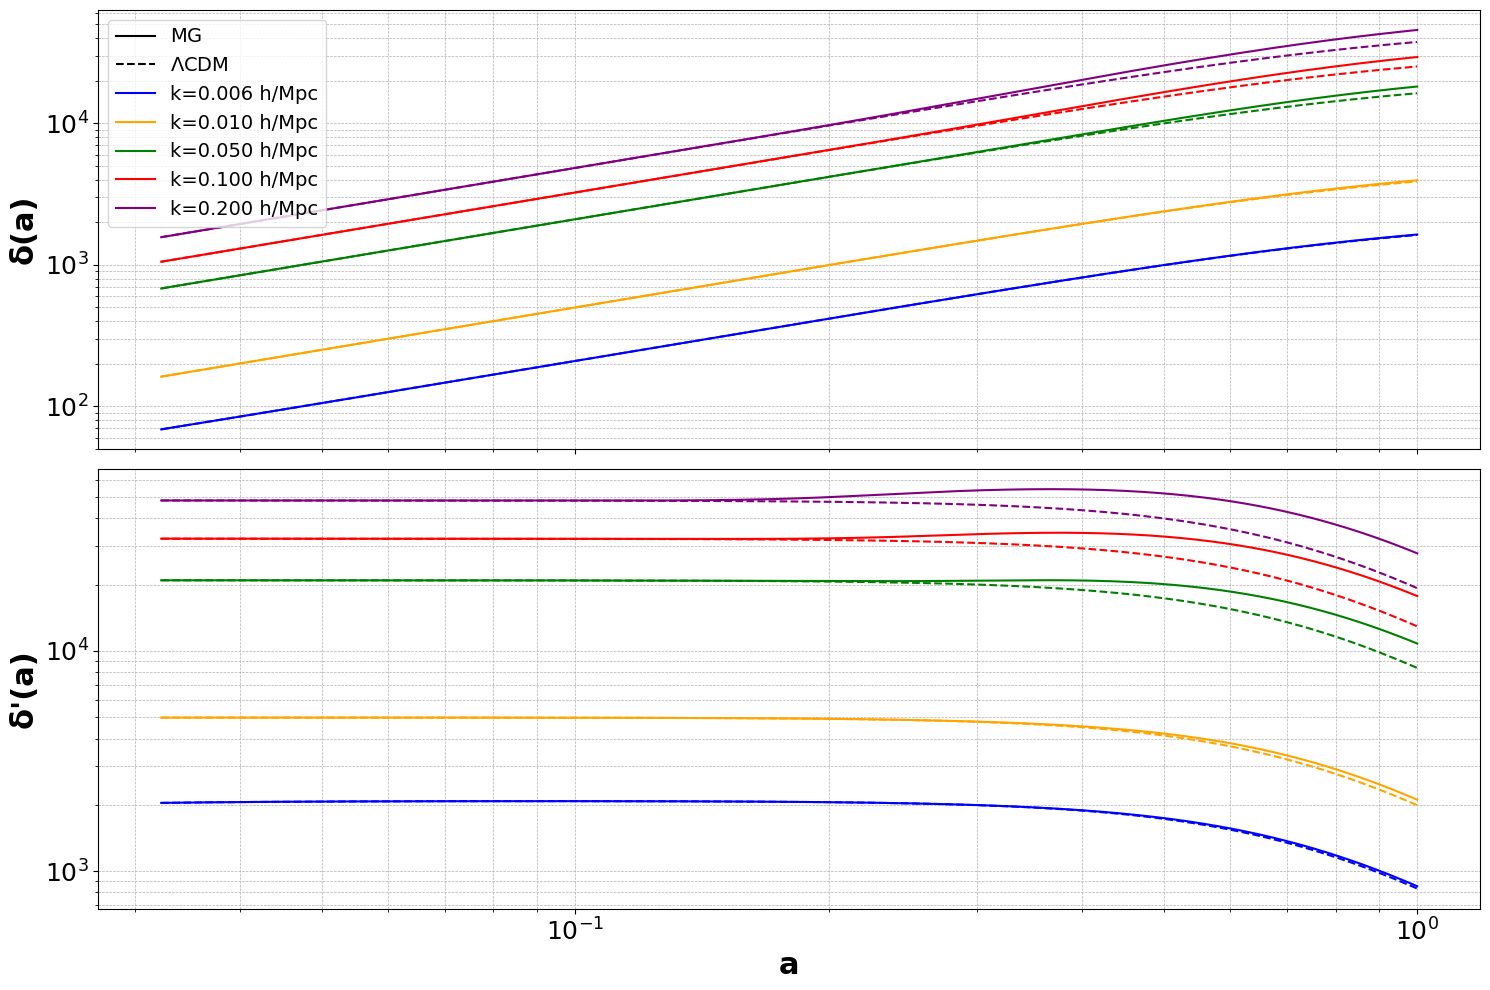

In [18]:
from matplotlib.lines import Line2D


k_thresholds = np.array([.006,.01, 0.05,.1,.3])/h #1/Mpc
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
# lista_dif_rel =[]
# arrs_difs = np.zeros((len(k_thresholds), len(df['a'].unique())))

line_style_elements = [
    Line2D([0], [0], color='black', linestyle='-', label=r'$\rm MG$'),
    Line2D([0], [0], color='black', linestyle='--', label=r'$\Lambda \rm CDM$')
]
line_style_elements2 = [
    Line2D([0], [0], color='black', linestyle='-', label=r'$\rm MG$'),
    Line2D([0], [0], color='black', linestyle='--', label=r'$\Lambda \rm CDM$')
]
color_elements =[]
#plot 3 delta_mg vs a_mg for 3 different ks
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
for i, k in enumerate(k_thresholds):
	idx = np.argmin(np.abs(mis_ks - k))
	axs[0].plot(a_mg, np.abs(delta_mg[idx, :]), '-', color = colors[i % len(colors)])
	axs[0].plot(a_LCDM, np.abs(delta_LCDM[idx, :]), '--', color = colors[i % len(colors)])
	axs[1].plot(a_mg, np.abs(delta_p_mg[idx, :]), '-', color = colors[i % len(colors)])
	axs[1].plot(a_LCDM, np.abs(delta_p_LCDM[idx, :]), '--', color = colors[i % len(colors)])
	color = colors[i % len(colors)]
	color_elements.append(
	Line2D([0], [0], color=color, linestyle='-', label=f'k={mis_ks[idx]*h:.3f} h/Mpc')
    )
axs[0].legend(handles=line_style_elements + color_elements, fontsize=14)
# axs[1].legend(handles=line_style_elements2 + color_elements)
axs[0].grid(True, which='both', linestyle='--', linewidth=.5)
axs[1].grid(True, which = 'both', linestyle = '--', linewidth = .5)
# axs[0].legend()	
# axs[1].legend()
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('a', fontsize=22, fontweight='bold')
axs[0].set_ylabel('δ(a)', fontsize=22, fontweight='bold')
axs[1].set_ylabel("δ'(a)", fontsize=22, fontweight='bold')
# Increase tick label sizes
axs[0].tick_params(axis='both', which='major', labelsize=18)
axs[1].tick_params(axis='both', which='major', labelsize=18)
# axs[0].set_title('Matter density contrast δ_mg(a) for different k modes')
# axs[1].set_title('Matter density contrast δ_LCDM(a) for different k modes')
plt.tight_layout()
plt.show()

### gráfico 2x2 con diferencias porcentuales

## Comparaciones misc. (NO correr)
Comparacion entre Solvers y verificación en el espacio de parámetros

### Comparaciones entre DeltaSolver y VectorizedDeltaSolver

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def benchmark_solvers(n_k=20, num_points=1000, n_jobs=16):
    """
    Compara el tiempo de cómputo entre DeltaSolver (secuencial) 
    y VectorizedDeltaSolver (paralelizado) para MG.
    """
    # Parámetros cosmológicos y del modelo f(R) base
    Om_m_0 = 0.305
    b = 0.1
    h = 0.68
    
    # Creamos un array de k logarítmico simulando el input real
    k_array = np.logspace(-3, 1, n_k)
    
    print(f"🚀 Iniciando benchmark para {n_k} valores de k...")
    print("-" * 50)
    
    # ---------------------------------------------------------
    # 1. Prueba con DeltaSolver (Secuencial)
    # ---------------------------------------------------------
    print("⏳ Calculando con DeltaSolver (Secuencial en bucle for)...")
    start_time_serial = time.perf_counter()
    
    delta_results_serial = []
    for k_val in tqdm(k_array, desc="Procesando k values"):
        # Instanciamos el solver clásico para cada k
        solver_serial = DeltaSolver(k=k_val, h=h, Om_m_0=Om_m_0, b=b)
        
        # Resolvemos las ecuaciones (internamente calcula H_HS, CI, y solve_ivp)
        a_num, delta_num, delta_p_num = solver_serial.solve_delta_mg(num_points=num_points)
        delta_results_serial.append(delta_num)
        
    end_time_serial = time.perf_counter()
    time_serial = end_time_serial - start_time_serial
    print(f"✅ Tiempo Secuencial: {time_serial:.2f} segundos")
    
    # ---------------------------------------------------------
    # 2. Prueba con VectorizedDeltaSolver (Paralelizado)
    # ---------------------------------------------------------
    print(f"\n⚡ Calculando con VectorizedDeltaSolver (Paralelizado a {n_jobs} cores)...")
    start_time_vec = time.perf_counter()
    
    # Instanciamos el solver vectorizado una sola vez
    solver_vec = VectorizedDeltaSolver(k_array=k_array, Om_m_0=Om_m_0, h=h, b=b, use_gpu=False)
    
    # Resolvemos usando el pool de multiprocessing
    a_vec, delta_results_vec, delta_p_results_vec = solver_vec.solve_delta_mg_vectorized_parallel(
        num_points=num_points, 
        n_jobs=n_jobs
    )
    
    end_time_vec = time.perf_counter()
    time_vec = end_time_vec - start_time_vec
    print(f"✅ Tiempo Paralelizado: {time_vec:.2f} segundos")
    
    # ---------------------------------------------------------
    # Resultados Finales
    # ---------------------------------------------------------
    speedup = time_serial / time_vec
    print("-" * 50)
    print(f"📊 RESUMEN DE RENDIMIENTO")
    print(f"El método vectorizado es {speedup:.2f} veces más rápido.")
    
    return time_serial, time_vec

# Ejecución del benchmark
if __name__ == '__main__':
    # Usamos 16 jobs por defecto como tenías seteado para tus cores
    t_seq, t_par = benchmark_solvers(n_k=1000, num_points=1000, n_jobs=16)

🚀 Iniciando benchmark para 1000 valores de k...
--------------------------------------------------
⏳ Calculando con DeltaSolver (Secuencial en bucle for)...


Procesando k values: 100%|██████████| 1000/1000 [19:25<00:00,  1.17s/it]

✅ Tiempo Secuencial: 1139.77 segundos

⚡ Calculando con VectorizedDeltaSolver (Paralelizado a 16 cores)...
VectorizedDeltaSolver usando: cpu
Resolviendo 1000 valores de k en paralelo con 16 procesos...


Resolución paralela completada.
✅ Tiempo Paralelizado: 149.29 segundos
--------------------------------------------------
📊 RESUMEN DE RENDIMIENTO
El método vectorizado es 7.63 veces más rápido.


### verificación del espacio de parámetros en f(R) (NO CORRER POR ERROR. NO ES NECESARIO PARA NADA ESTO)

In [ ]:
asd=0.008
print(1/asd - 1)

124.0


In [ ]:
z_hs =50
a_hs = 1.0/(1.0 + z_hs)
print("a_hs =", a_hs)

a_hs = 0.0196078431372549


Generando Heatmaps MG vs LCDM...
Inicio: a=0.008 -> Evaluar en: a=0.03
Parámetros: k=0.2 h/Mpc, b=0.5


Procesando:   0%|          | 0/20 [00:00<?, ?it/s]

VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16

Procesando:   5%|▌         | 1/20 [00:59<18:48, 59.41s/it]

Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolvie

...

Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolvie

Procesando:  95%|█████████▌| 19/20 [17:49<00:56, 56.23s/it]

Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolviendo 1 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 1 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
VectorizedDeltaSolver usando: cuda
Resolvie

Procesando: 100%|██████████| 20/20 [18:45<00:00, 56.27s/it]

Resolución paralela LCDM completada.


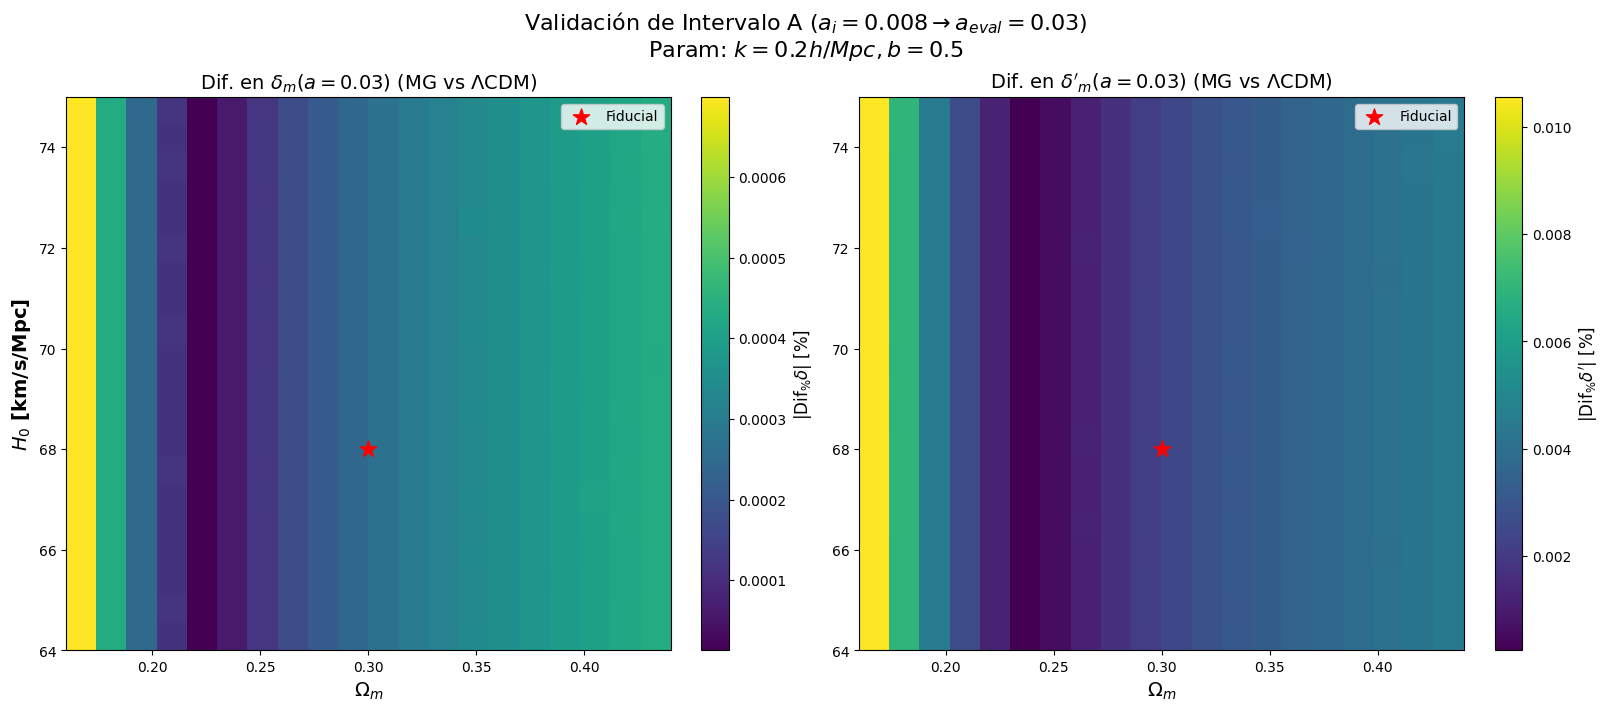

Máx dif Delta': 0.0106%
CONCLUSIÓN: El punto a=0.03 es seguro (dif < 1%) para todo el espacio de parámetros.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# Asumo que importas tu librería así
import funciones_tesis as ft 
# Asumo que VectorizedDeltaSolver está disponible en el entorno

# --- 1. CONFIGURACIÓN ---
# Resolución de la grilla (ajustar según potencia de cálculo)
resolution = 20
omega_m_vals = np.linspace(0.16, 0.44, resolution) 
h0_vals = np.linspace(64, 75, resolution)

# Parámetros fijos
k_target_h = 0.2      # [h/Mpc]
a_start = 0.008       # Inicio de integración (condición inicial común)
a_eval = 0.03         # Punto de evaluación (donde chequeamos la diferencia)
b_param = 0.5         # Parámetro Hu-Sawicki (caso extremo conservador)


# Matrices para guardar los errores
grid_diff_delta = np.zeros((len(h0_vals), len(omega_m_vals)))
grid_diff_prime = np.zeros((len(h0_vals), len(omega_m_vals)))

print(f"Generando Heatmaps MG vs LCDM...")
print(f"Inicio: a={a_start} -> Evaluar en: a={a_eval}")
print(f"Parámetros: k={k_target_h} h/Mpc, b={b_param}")

# --- 2. BUCLE SOBRE EL ESPACIO DE PARÁMETROS ---
for i, h0 in enumerate(tqdm(h0_vals, desc="Procesando")):
    for j, om in enumerate(omega_m_vals):
        
        # Calcular parámetros derivados
        h_param = h0 / 100.0
        z_start = 1.0/a_start - 1.0 # Redshift inicial para el solver
        
        # Convertir k a 1/Mpc (unidades físicas para el solver)
        k_in_1_Mpc = k_target_h * h_param
        
        try:
            # Instanciar solver con inicio en a=0.008
            # Nota: k_array debe ser un array numpy
            solver = VectorizedDeltaSolver(
                k_array=np.array([k_in_1_Mpc]), 
                h=h_param, 
                Om_m_0=om, 
                b=b_param, 
                z_0=z_start,
                z_ini_HS=40
            )
            
            # Resolver ambos modelos (integración completa)
            # MG
            a_vec_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel()
            # LCDM
            a_vec_lcdm, delta_lcdm, delta_p_lcdm = solver.solve_delta_lcdm_vectorized_parallel()
            
            # --- 3. INTERPOLAR EN a = 0.03 ---
            # El solver devuelve arrays de evolución [n_k, n_pasos]
            # Tomamos el índice k=0
            d_mg_at_eval = np.interp(a_eval, a_vec_mg, delta_mg[0, :])
            d_lcdm_at_eval = np.interp(a_eval, a_vec_lcdm, delta_lcdm[0, :])
            
            p_mg_at_eval = np.interp(a_eval, a_vec_mg, delta_p_mg[0, :])
            p_lcdm_at_eval = np.interp(a_eval, a_vec_lcdm, delta_p_lcdm[0, :])
            
            # --- 4. CALCULAR DIFERENCIA PORCENTUAL ---
            if abs(d_lcdm_at_eval) > 1e-12:
                diff_d = abs((d_mg_at_eval - d_lcdm_at_eval) / d_lcdm_at_eval) * 100
            else:
                diff_d = 0.0
                
            if abs(p_lcdm_at_eval) > 1e-12:
                diff_p = abs((p_mg_at_eval - p_lcdm_at_eval) / p_lcdm_at_eval) * 100
            else:
                diff_p = 0.0
            
            grid_diff_delta[i, j] = diff_d
            grid_diff_prime[i, j] = diff_p
            
        except Exception as e:
            print(f"Error en h={h0}, om={om}: {e}")
            grid_diff_delta[i, j] = np.nan
            grid_diff_prime[i, j] = np.nan

# --- 5. GRAFICAR ---
fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
extent = [omega_m_vals.min(), omega_m_vals.max(), h0_vals.min(), h0_vals.max()]

# Heatmap 1: Delta
im1 = axs[0].imshow(grid_diff_delta, extent=extent, origin='lower', aspect='auto', cmap='viridis')
axs[0].set_title(rf'Dif. en $\delta_m(a={a_eval})$ (MG vs $\Lambda$CDM)', fontsize=14)
axs[0].set_xlabel(r'$\Omega_m$', fontsize=14, fontweight='bold')
axs[0].set_ylabel(r'$H_0$ [km/s/Mpc]', fontsize=14, fontweight='bold')
cb1 = plt.colorbar(im1, ax=axs[0])
cb1.set_label(r'$|\mathrm{Dif}_{\%}\delta|$ [%]', fontsize=12)
# Contorno de 1%
axs[0].contour(grid_diff_delta, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')

# Heatmap 2: Delta Prime
im2 = axs[1].imshow(grid_diff_prime, extent=extent, origin='lower', aspect='auto', cmap='viridis')
axs[1].set_title(rf"Dif. en $\delta'_m(a={a_eval})$ (MG vs $\Lambda$CDM)", fontsize=14)
axs[1].set_xlabel(r'$\Omega_m$', fontsize=14, fontweight='bold')
cb2 = plt.colorbar(im2, ax=axs[1])
cb2.set_label(r"$|\mathrm{Dif}_{\%}\delta'|$ [%]", fontsize=12)
# Contorno de 1%
CS2 = axs[1].contour(grid_diff_prime, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')
axs[1].clabel(CS2, fmt='%1.1f%%', inline=True, fontsize=10)

# Título General
fig.suptitle(f'Validación de Intervalo A ($a_i={a_start} \\to a_{{eval}}={a_eval}$)\nParam: $k={k_target_h} h/Mpc, b={b_param}$', fontsize=16)

# Marcar fiducial
for ax in axs:
    ax.scatter([0.3], [68], color='red', marker='*', s=150, label='Fiducial', zorder=10)
    ax.legend(loc='upper right')

plt.show()

# Mensaje diagnóstico
print(f"Máx dif Delta': {np.nanmax(grid_diff_prime):.4f}%")
if np.nanmax(grid_diff_prime) < 1.0:
    print("CONCLUSIÓN: El punto a=0.03 es seguro (dif < 1%) para todo el espacio de parámetros.")
else:
    print("ATENCIÓN: Hay regiones donde MG se separa de LCDM antes de a=0.03.")

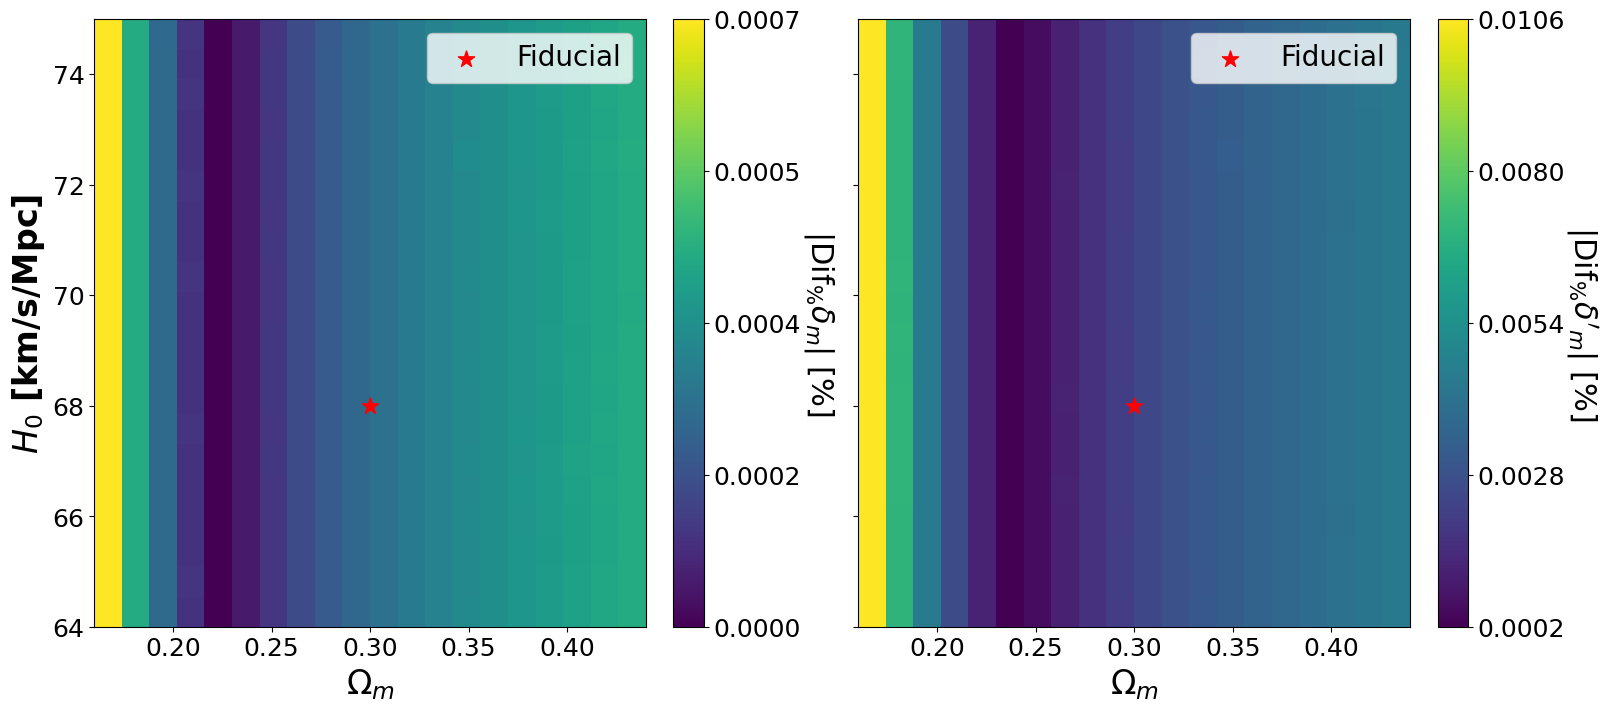

Máx dif Delta': 0.0106%
CONCLUSIÓN: El punto a=0.03 es seguro (dif < 1%) para todo el espacio de parámetros.


In [ ]:
# --- 5. GRAFICAR ---
fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True, sharey='row')
extent = [omega_m_vals.min(), omega_m_vals.max(), h0_vals.min(), h0_vals.max()]

# Heatmap 1: Delta
im1 = axs[0].imshow(grid_diff_delta, extent=extent, origin='lower', aspect='auto', cmap='viridis')
# axs[0].set_title(rf'Dif. en $\delta_m(a={a_eval})$ (MG vs $\Lambda$CDM)', fontsize=16)
axs[0].set_xlabel(r'$\Omega_m$', fontsize=24, fontweight='bold')
axs[0].set_ylabel(r'$H_0$ [km/s/Mpc]', fontsize=24, fontweight='bold')
cb1 = plt.colorbar(im1, ax=axs[0])
cb1.set_label(r'$|\mathrm{Dif}_{\%}\delta_m|$ [%]', rotation=270, labelpad=25, fontsize=22)
cb1.ax.tick_params(labelsize=18)
# Set appropriate ticks for delta
tick_values_1 = np.linspace(grid_diff_delta.min(), grid_diff_delta.max(), 5)
cb1.set_ticks(tick_values_1)
cb1.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4f}'))

# Contorno de 1%
axs[0].contour(grid_diff_delta, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')

# Heatmap 2: Delta Prime
im2 = axs[1].imshow(grid_diff_prime, extent=extent, origin='lower', aspect='auto', cmap='viridis')
# axs[1].set_title(rf"Dif. en $\delta'_m(a={a_eval})$ (MG vs $\Lambda$CDM)", fontsize=14)
axs[1].set_xlabel(r'$\Omega_m$', fontsize=24, fontweight='bold')
# axs[1].set_ylabel(r'$H_0$ [km/s/Mpc]', fontsize=24, fontweight='bold')
cb2 = plt.colorbar(im2, ax=axs[1])
cb2.set_label(r"$|\mathrm{Dif}_{\%}\delta'_m|$ [%]", rotation=270, labelpad=25, fontsize=22)
cb2.ax.tick_params(labelsize=18)
# Set appropriate ticks for delta prime
tick_values_2 = np.linspace(grid_diff_prime.min(), grid_diff_prime.max(), 5)
cb2.set_ticks(tick_values_2)
cb2.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4f}'))

# Contorno de 1%
CS2 = axs[1].contour(grid_diff_prime, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')
axs[1].clabel(CS2, fmt='%1.1f%%', inline=True, fontsize=24)

# Título General
# fig.suptitle(f'Validación de Intervalo A ($a_i={a_start} \\to a_{{eval}}={a_eval}$)\nParam: $k={k_target_h} h/Mpc, b={b_param}$', fontsize=16)

# Marcar fiducial
for ax in axs:
    ax.scatter([0.3], [68], color='red', marker='*', s=150, label='Fiducial', zorder=10)
    ax.legend(loc='upper right', fontsize=20)
    #bigger x and y ticks
    ax.tick_params(axis='both', which='major', labelsize=18)

plt.show()

# Mensaje diagnóstico
print(f"Máx dif Delta': {np.nanmax(grid_diff_prime):.4f}%")
if np.nanmax(grid_diff_prime) < 1.0:
    print("CONCLUSIÓN: El punto a=0.03 es seguro (dif < 1%) para todo el espacio de parámetros.")
else:
    print("ATENCIÓN: Hay regiones donde MG se separa de LCDM antes de a=0.03.")

/tmp/ipykernel_1040/3883189715.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


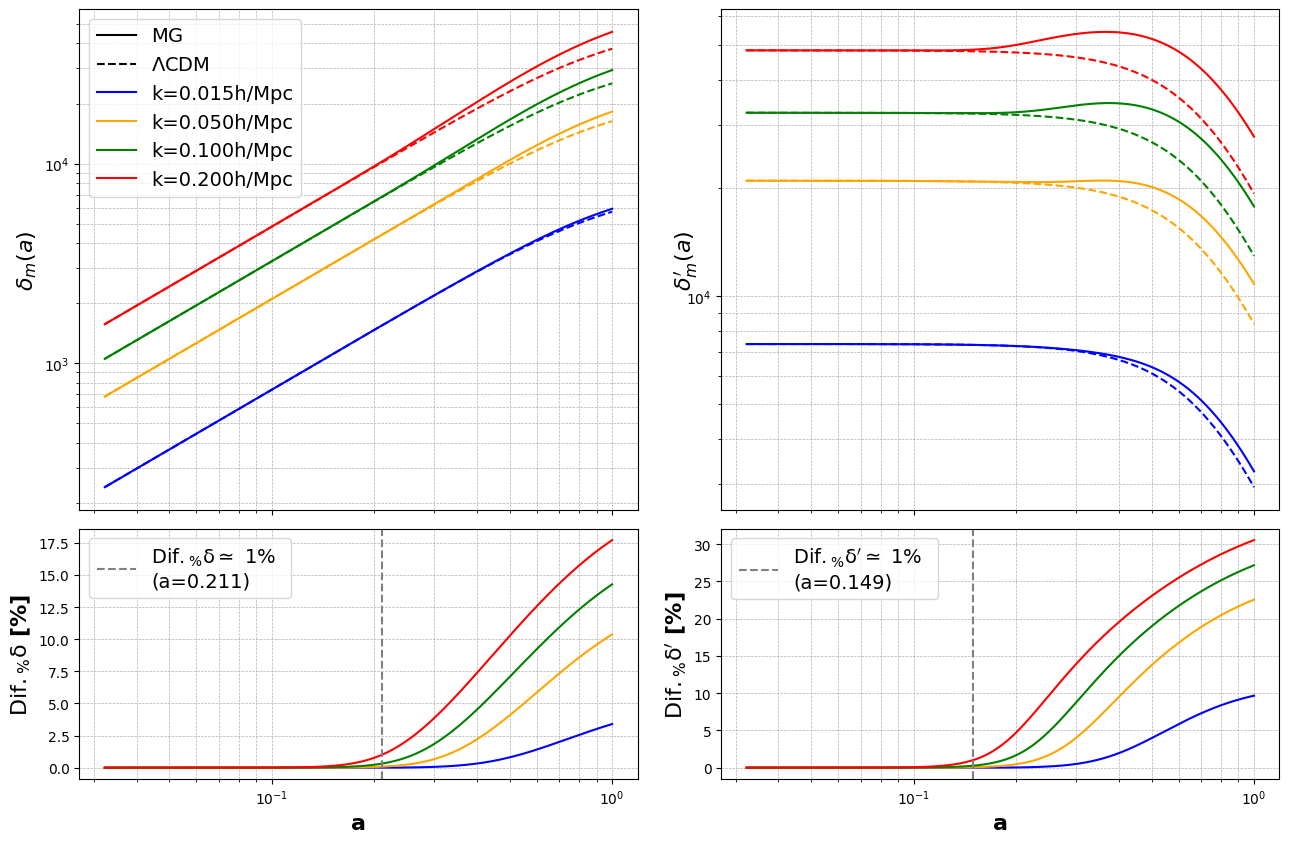

In [9]:
from matplotlib.lines import Line2D


k_thresholds = np.array([.015, 0.05,.1,.3])/h #1/Mpc
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
# lista_dif_rel =[]
# arrs_difs = np.zeros((len(k_thresholds), len(df['a'].unique())))

line_style_elements = [
    Line2D([0], [0], color='black', linestyle='-', label=r'$\rm MG$'),
    Line2D([0], [0], color='black', linestyle='--', label=r'$\Lambda \rm CDM$')
]
line_style_elements2 = [
    Line2D([0], [0], color='black', linestyle='-', label=r'$\rm MG$'),
    Line2D([0], [0], color='black', linestyle='--', label=r'$\Lambda \rm CDM$')
]
color_elements =[]
#plot 3 delta_mg vs a_mg for 3 different ks
fig, axs = plt.subplots(2, 2, figsize=(15, 10),
                        gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05, 'wspace': 0.15},
                        sharex='col')
for i, k in enumerate(k_thresholds):
	idx = np.argmin(np.abs(mis_ks - k))
	dif_deltas = ft.percent_diff_vs_class(a_mg, delta_mg[idx, :], a_LCDM, delta_LCDM[idx, :])
	dif_deltas_p = ft.percent_diff_vs_class(a_mg, delta_p_mg[idx, :], a_LCDM, delta_p_LCDM[idx, :])
	axs[0,0].plot(a_mg, np.abs(delta_mg[idx, :]), '-', color = colors[i % len(colors)])
	axs[0,0].plot(a_LCDM, np.abs(delta_LCDM[idx, :]), '--', color = colors[i % len(colors)])
	axs[0,1].plot(a_mg, np.abs(delta_p_mg[idx, :]), '-', color = colors[i % len(colors)])
	axs[0,1].plot(a_LCDM, np.abs(delta_p_LCDM[idx, :]), '--', color = colors[i % len(colors)])
	axs[1,0].plot(a_mg, dif_deltas, '-', color = colors[i % len(colors)])
	axs[1,1].plot(a_mg, dif_deltas_p, '-', color = colors[i % len(colors)])
	color = colors[i % len(colors)]
	color_elements.append(
	Line2D([0], [0], color=color, linestyle='-', label=f'k={mis_ks[idx]*h:.3f}h/Mpc')
    )
 
#a_i donde la diferencia comienza a ser > 1%
a_diff_1pct_delta_index = np.where(np.abs(dif_deltas) > 1)[0]
a_diff_1pct_delta_prime_index = np.where(np.abs(dif_deltas_p) > 1)[0]
lines_elements1= []
lines_elements2 = []
#plot vertical lines at these a_i
if len(a_diff_1pct_delta_index) > 0:
	a_1pct_delta = a_mg[a_diff_1pct_delta_index[0]]
	axs[1,0].axvline(x=a_1pct_delta, color='gray', linestyle='--')
	# axs[0,0].axvline(x=a_1pct_delta, color='gray', linestyle='--')
	lines_elements1.append(
	Line2D([0], [0], color='gray', linestyle='--', label=r'$\mathrm{Dif._\% \delta}\simeq$ 1% '+ f' \n(a={a_1pct_delta:.3f})')
	)
if len(a_diff_1pct_delta_prime_index) > 0:
	a_1pct_delta_prime = a_mg[a_diff_1pct_delta_prime_index[0]]
	axs[1,1].axvline(x=a_1pct_delta_prime, color='gray', linestyle='--')
	# axs[0,1].axvline(x=a_1pct_delta_prime, color='gray', linestyle='--')
	lines_elements2.append(
	Line2D([0], [0], color='gray', linestyle='--', label=r'$\mathrm{Dif._\% \delta^\prime}\simeq$ 1% '+ f' \n(a={a_1pct_delta_prime:.3f})')
	)

 

axs[0,0].legend(handles=line_style_elements + color_elements , fontsize = 14)
axs[1,0].legend(handles=lines_elements1, fontsize = 14)
axs[1,1].legend(handles=lines_elements2, fontsize = 14)
# axs[0,1].legend(handles=line_style_elements2 + color_elements + lines_elements2)
axs[0,0].grid(True, which='both', linestyle='--', linewidth=.5)
axs[0,1].grid(True, which = 'both', linestyle = '--', linewidth = .5)
axs[1,0].grid(True, which='both', linestyle='--', linewidth=.5)
axs[1,1].grid(True, which = 'both', linestyle = '--', linewidth = .5)
# axs[0].legend()	
# axs[1].legend()
axs[0,0].set_xscale('log')
axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')
axs[0,0].set_yscale('log')
axs[0,1].set_yscale('log')
# axs[1,0].set_yscale('log')
axs[0,1].set_yscale('log')
# axs[1,1].set_yscale('log')
#all scales log
plt.subplots_adjust(left=0.1)  # Ajusta el margen izquierdo
axs[1,0].set_xlabel('a', fontsize=16, fontweight='bold')
axs[1,1].set_xlabel('a', fontsize=16, fontweight='bold')
axs[0,0].set_ylabel('$\delta_m(a)$', fontsize=16, fontweight='bold')
axs[0,1].set_ylabel("$\delta_m'(a)$", fontsize=16, fontweight='bold', labelpad=-10)
axs[1,0].set_ylabel(r'$\mathrm{Dif._\% \delta}$ [%]', fontsize=16, fontweight='bold')
axs[1,1].set_ylabel(r'$\mathrm{Dif._\% \delta^\prime}$ [%]', fontsize=16, fontweight='bold')
# axs[0].set_title('Matter density contrast δ_mg(a) for different k modes')
# axs[1].set_title('Matter density contrast δ_LCDM(a) for different k modes')
plt.tight_layout()
plt.show()


# Cómputo de $f\sigma_8$

## $\sigma_8$(z)

### Compute cosas
Solo calcular a partir de $z=3$

In [24]:
z = 2.0
idx_z = np.argmin(np.abs(z_mg - z))
#deltas bewteen z=0 and z=2 for all ks
deltas_mg_z = delta_mg[:, idx_z:]
deltas_LCDM_z = delta_LCDM[:, idx_z:]
#delta_p between z=0 and z=2 for all ks
deltas_p_mg_z = delta_p_mg[:, idx_z:]
deltas_p_LCDM_z = delta_p_LCDM[:, idx_z:]
z_s8_idx = z_mg[idx_z:]
a_s8_idx = a_mg[idx_z:]


In [25]:
#compute sigma8
sigma8_lcdm = solver.compute_sigma8_vectorized(deltas = deltas_LCDM_z)

In [26]:
sigma8_mg = solver.compute_sigma8_vectorized(deltas = deltas_mg_z)

In [27]:
print("sigma8(z=0) LCDM:", sigma8_lcdm[-1])
print("sigma8(z=0) MG:", sigma8_mg[-1])

sigma8(z=0) LCDM: 4.449400857242218
sigma8(z=0) MG: 5.058896127293029


In [28]:
#idx where z = 3
z_LCDM = 1/a_LCDM - 1
idx_lcdm = np.argmin(np.abs(z_LCDM - 3))
idx_mg = np.argmin(np.abs(z_mg - 3))

sigma8_lcdm_z3 = sigma8_lcdm[:]
sigma8_mg_z3 = sigma8_mg
z_idxs_LCDM = z_LCDM[idx_lcdm:]
z_idxs_MG = z_mg[idx_mg:]
print('sigma8(z=0) LCDM:', sigma8_lcdm[-1])
print('sigma8(z=0) MG:', sigma8_mg[-1])

sigma8(z=0) LCDM: 4.449400857242218
sigma8(z=0) MG: 5.058896127293029


In [29]:
#save in csv sigma8, z and a
df_sigma8 = pd.DataFrame({'a':a_s8_idx, 'z': z_s8_idx, 'sigma8_LCDM': sigma8_lcdm_z3,
						  'sigma8_MG': sigma8_mg_z3})
# df_sigma8.head()
df_sigma8.to_csv(f'{path}/sigma8_vs_z_nuevo_prim_PS.csv', index=False)

### Cargar cosas

In [10]:
df_sigma8 = pd.read_csv(f'{path}/sigma8_vs_z2.csv')
df_sigma8.head()

NameError: name 'path' is not defined

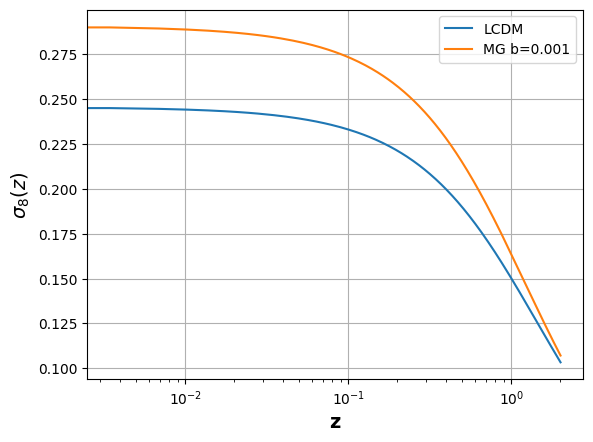

In [ ]:
#plot sigma 8 vs z
z_mg_z = df_sigma8['z'].values
sigma8_lcdm = df_sigma8['sigma8_LCDM'].values
sigma8_mg = df_sigma8['sigma8_MG'].values
plt.plot(z_mg_z, sigma8_lcdm, label='LCDM')
plt.plot(z_mg_z, sigma8_mg, label='MG b=0.001')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('$\sigma_8(z)$', fontsize=14, fontweight='bold')
plt.xscale('log')
# plt.yscale('log')
# plt.title('sigma8(z) vs z')
plt.legend()
plt.grid()
plt.show()

## $f\sigma_8(z)$

In [19]:
import funciones_tesis as ft
import importlib
import sys
sys.path.append('../python/')
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
import numpy as np
import matplotlib.pyplot as plt
# path = '/home/pedrorozin/scripts/outputs_pedro/modified_gravity'



In [20]:
#print modules of the class and check if 'f_k' is in any of them
# print(dir(VectorizedDeltaSolver))
for attr in dir(VectorizedDeltaSolver):
	if 'f_k' in attr:
		print(attr)

compute_f_k_vectorized
compute_f_with_f_k
compute_f_with_f_k_exp


In [21]:
# mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 100)  # k en 1/Mpc
# solver = VectorizedDeltaSolver(k_array=mis_ks, h=0.68, Om_m_0=0.3, b=0.001)
# a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel()
# a_LCDM, delta_LCDM, delta_p_LCDM = solver.solve_delta_lcdm_vectorized_parallel()
# z_mg = 1/a_mg - 1

#load df from csv
df_sigma8 = pd.read_csv(f'{path}/sigma8_vs_z2.csv')
sigma8_lcdm = df_sigma8['sigma8_LCDM'].values
print(len(sigma8_lcdm))
df_sigma8.head()

321


,a,z,sigma8_LCDM,sigma8_MG
0,0.332879,2.004094,0.103338,0.107128
1,0.334025,1.993785,0.103678,0.107519
2,0.335175,1.983512,0.104019,0.107911
3,0.336330,1.973274,0.104361,0.108304
4,0.337488,1.963071,0.104703,0.108699


### f en $\Lambda CDM$


In [22]:
solver = VectorizedDeltaSolver(k_array=mis_ks, h=0.68, Om_m_0=0.3, b=0.001)

VectorizedDeltaSolver usando: cuda


In [23]:
#compute f_k
idx_z = np.argmin(np.abs(z_mg - 2.0))
a_z= a_mg[idx_z:]
# a_z= df_sigma8['a'].values
deltas_LCDM_z = delta_LCDM[:, idx_z:]
deltas_p_LCDM_z = delta_p_LCDM[:, idx_z:]

ks, z, f_k_LCDM = solver.compute_f_k_vectorized(a_vec=a_z, delta=deltas_LCDM_z, delta_p=deltas_p_LCDM_z)
print(len(f_k_LCDM[0,:]), len(z))
# print(z)


321 321


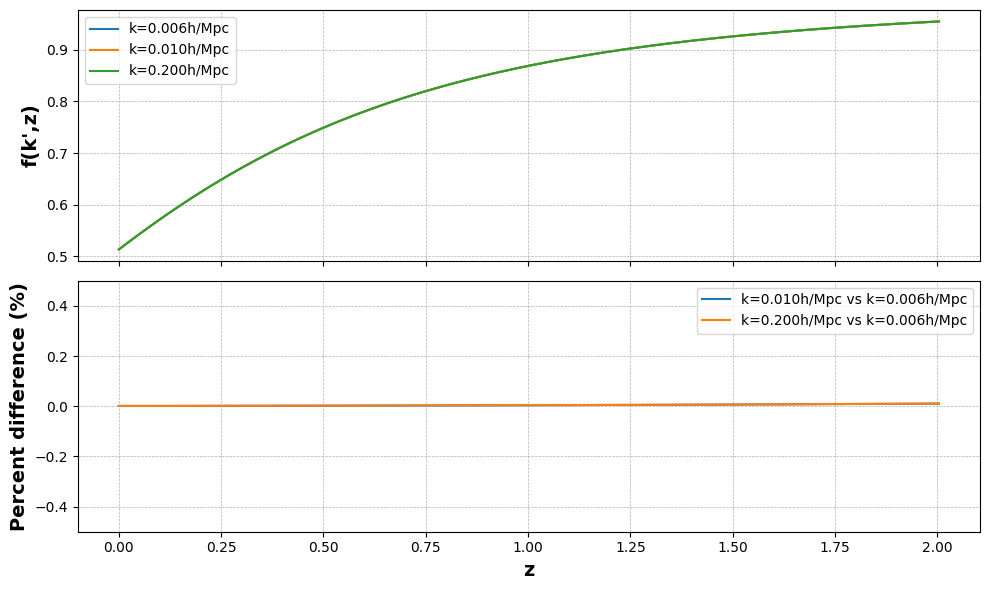

In [24]:
#plot f_k for different ks and their percent difference
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i, k in enumerate(np.array([.006,.01,.2])/solver.h):
	idx = np.argmin(np.abs(ks - k))
	axs[0].plot(z, f_k_LCDM[idx, :], label=f'k={k*solver.h:.3f}h/Mpc')
	if i > 0:
		percent_diff = (f_k_LCDM[idx, :] - f_k_LCDM[0, :]) / f_k_LCDM[0, :] * 100
		axs[1].plot(z, percent_diff, label=f'k={k*solver.h:.3f}h/Mpc vs k={ks[0]*solver.h:.3f}h/Mpc')
axs[0].set_ylabel("f(k',z)", fontsize=14, fontweight='bold')
axs[1].set_ylabel('Percent difference (%)', fontsize=14, fontweight='bold')
axs[1].set_xlabel('z', fontsize=14, fontweight='bold')
axs[0].legend()
axs[1].legend()
axs[0].grid(True, which='both', linestyle='--', linewidth=.5)
axs[1].set_ylim(-.5, .5)
axs[1].grid(True, which = 'both', linestyle = '--', linewidth = .5)
plt.tight_layout()
plt.show()
	

In [25]:
f_z_integrando = np.real(solver.compute_f_with_f_k(z_vec=z, f_k_array=f_k_LCDM, use_mg_hubble=False, k_array=ks))
f_z_debug_LCDM, H_debug_LCDM, z_debug_LCDM, x_fisico_debug_LCDM = solver.compute_f_with_f_k(z_vec=z, f_k_array=f_k_LCDM, use_mg_hubble=False, k_array=ks, debug=True)
print(len(f_z_integrando), len(z))
# f_z_integrando

/home/pedrorozin/scripts/python/delta_solver_mg_pedro.py:1057: RuntimeWarning: divide by zero encountered in log10
  z_int = np.logspace(np.log10(0.0001), np.log10(z), 1000)
/home/pedrorozin/scripts/venv/lib/python3.10/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step


DEBUG: Calculando distancias físicas x(z)
En z=2.00, x(z)=5336.88 Mpc. La integral da (sin ctes).: 1.21 Mpc
En z=1.90, x(z)=5182.77 Mpc. La integral da (sin ctes).: 1.18 Mpc
En z=1.80, x(z)=5026.69 Mpc. La integral da (sin ctes).: 1.14 Mpc
En z=1.71, x(z)=4868.68 Mpc. La integral da (sin ctes).: 1.10 Mpc
En z=1.62, x(z)=4708.79 Mpc. La integral da (sin ctes).: 1.07 Mpc
En z=1.53, x(z)=4547.10 Mpc. La integral da (sin ctes).: 1.03 Mpc
En z=1.44, x(z)=4383.66 Mpc. La integral da (sin ctes).: 0.99 Mpc
En z=1.36, x(z)=4218.56 Mpc. La integral da (sin ctes).: 0.96 Mpc
En z=1.28, x(z)=4051.90 Mpc. La integral da (sin ctes).: 0.92 Mpc
En z=1.20, x(z)=3883.78 Mpc. La integral da (sin ctes).: 0.88 Mpc
En z=1.13, x(z)=3714.31 Mpc. La integral da (sin ctes).: 0.84 Mpc
En z=1.06, x(z)=3543.62 Mpc. La integral da (sin ctes).: 0.80 Mpc
En z=0.99, x(z)=3371.85 Mpc. La integral da (sin ctes).: 0.76 Mpc
En z=0.92, x(z)=3199.15 Mpc. La integral da (sin ctes).: 0.73 Mpc
En z=0.86, x(z)=3025.69 Mpc. La in

In [26]:
#difference between f(z) from f_k and f(z) from delta at the start
dif_ini= f_k_LCDM[0, 0]/f_z_integrando[0]
mean_dif = np.mean(f_k_LCDM[0, :-1]/f_z_integrando[:-1])
print("Difference at z ini:", dif_ini)
print("Mean difference over z:", mean_dif)
print(dif_ini, 2*np.pi**2, 1/(solver.h**3))
print(4*np.pi**2/solver.h**3)

Difference at z ini: 12958455.656272605
Mean difference over z: 625089.5620226087
12958455.656272605 19.739208802178716 3.1803378790962746
125.55470691391915


### $f\sigma_8(z)$ para $\Lambda CDM$:

Para LCDM da bien la pinta funcional si usamos que es scale-dependent (hay una constante que molesta todavía). El problema está en la transformada de Fourier de f_k

<!-- Nota: cuando hago $\Lambda CDM$, estoy calculando: $'f\sigma_8(z)' = a(z) \frac{\delta '(z)}{\delta (z=0)}  $ (no estoy multiplicando por $\sigma_8$ todavía) -->

In [27]:
from classy import Class
import funciones_tesis as ft

model = ft.common_settings(h=solver.h, omega_m=solver.Om_m_0, A_s=2e-9)
sigma8_class = ft.get_sigma8(model)
print("sigma8 from class:", sigma8_class)


sigma8 from class: 0.787709890469588


In [28]:
sigma8_lcdm_z0 = sigma8_lcdm[0]
print("sigma8 from solver at z=0:", sigma8_lcdm_z0)

sigma8 from solver at z=0: 0.1033382070396948


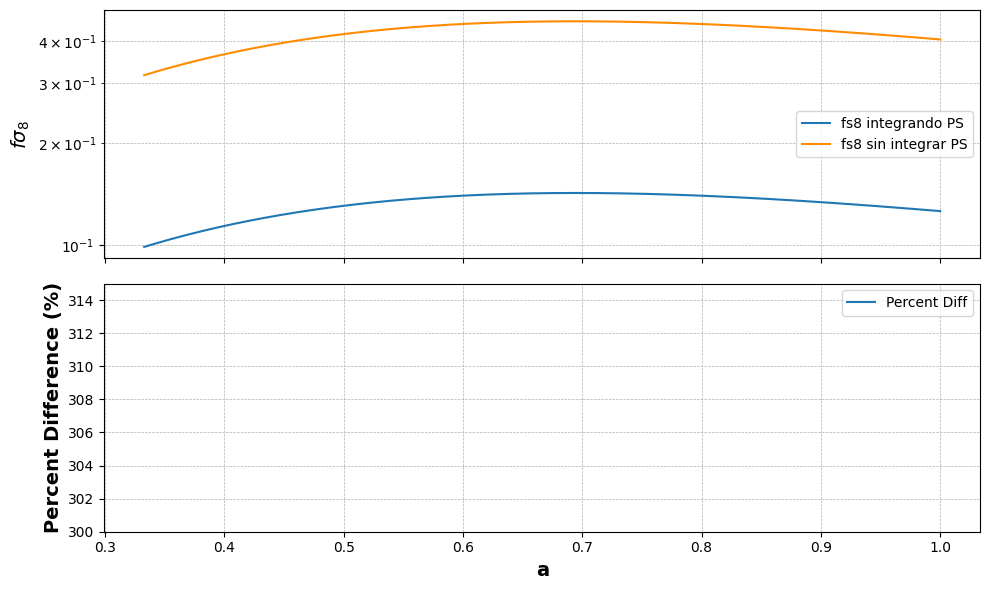

In [29]:

fsigma8_de_siempre = sigma8_class * deltas_p_LCDM_z[0,:] / deltas_LCDM_z[0,-1] * a_z
f_sigma8_LCDM = f_k_LCDM[0,:] * sigma8_lcdm
percent_difference = np.abs(f_sigma8_LCDM - fsigma8_de_siempre) / f_sigma8_LCDM * 100
ratio_medio = np.mean(fsigma8_de_siempre / f_sigma8_LCDM)
fsigma8_de_siempre_norm = fsigma8_de_siempre / ratio_medio
dif_normalizada = np.abs(f_sigma8_LCDM - fsigma8_de_siempre_norm) / f_sigma8_LCDM * 100
fig, ax =plt.subplots(2,1, figsize=(10,6), sharex=True)
#plot both fs8 and percent difference
# ax[0].plot(a_z, fsigma8_de_siempre, label='fs8 sin integrar PS')

ax[0].plot(a_z, f_sigma8_LCDM, label='fs8 integrando PS')
ax[0].plot(a_z, fsigma8_de_siempre, label='fs8 sin integrar PS', color ='darkorange')
# ax[0].plot(a_z, fsigma8_de_siempre_norm, label='fs8 sin integrar PS (normalizado)', linestyle='--', color ='darkorange')
#grid and logscale
ax[0].grid(True, which='both', linestyle='--', linewidth=.5)
ax[0].set_yscale('log')
ax[0].legend()
# ax[0].set_xlabel('a')
ax[0].set_ylabel('$f\sigma_8$', fontsize=14, fontweight='bold')

ax[1].plot(a_z, percent_difference, label='Percent Diff')
# ax[1].plot(a_z, dif_normalizada, label='Percent Diff.',  color='darkorange')
#scale between 0 and 15
ax[1].set_ylim(300, 315)
# ax[1].set_ylim(-.5, .5)
ax[1].grid(True, which='both', linestyle='--', linewidth=.5)
ax[1].set_xlabel('a', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Percent Difference (%)', fontsize=14, fontweight='bold')
ax[1].legend()

plt.tight_layout()
plt.show()

h^3 = 0.31443200000000004
ratio medio fs8 (f_k/sigma8) / fs8 (de siempre): 0.311604099299028


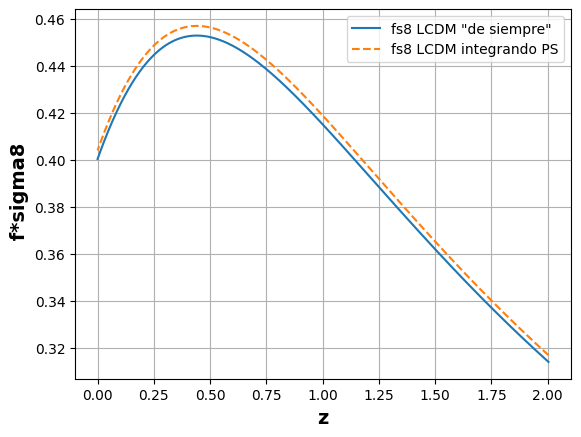

In [30]:
# fsigma8_de_siempre = deltas_p_LCDM_z[0,:] / deltas_LCDM_z[0,-1] * a_z
f_sigma8_LCDM = f_k_LCDM[0,:] * sigma8_lcdm
# f_sigma8_integrando = f_z_integrando * sigma8_lcdm
# ratio_medio2= np.mean(f_sigma8_integrando/fsigma8_de_siempre)
ratio_medio = np.mean(f_sigma8_LCDM/fsigma8_de_siempre)
h = solver.h
chain_rule = 1/h**3
print(f'h^3 = {solver.h**3}')
print("ratio medio fs8 (f_k/sigma8) / fs8 (de siempre):", ratio_medio)
plt.plot(z, f_sigma8_LCDM*chain_rule, label='fs8 LCDM "de siempre"')
# plt.plot(z, f_sigma8_LCDM, label='fs8 LCDM integrando PS', linewidth=3)
plt.plot(z, fsigma8_de_siempre, '--', label='fs8 LCDM integrando PS')

plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel(' f*sigma8', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

$h^3$ = 0.314432
Ratio medio $f\sigma_8$ (método 1 / método 2): 0.311604

DIFERENCIAS PORCENTUALES ENTRE MÉTODOS:
  Diferencia máxima:  0.9102%
  Diferencia media:   0.9078%



/tmp/ipykernel_1648/582341995.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


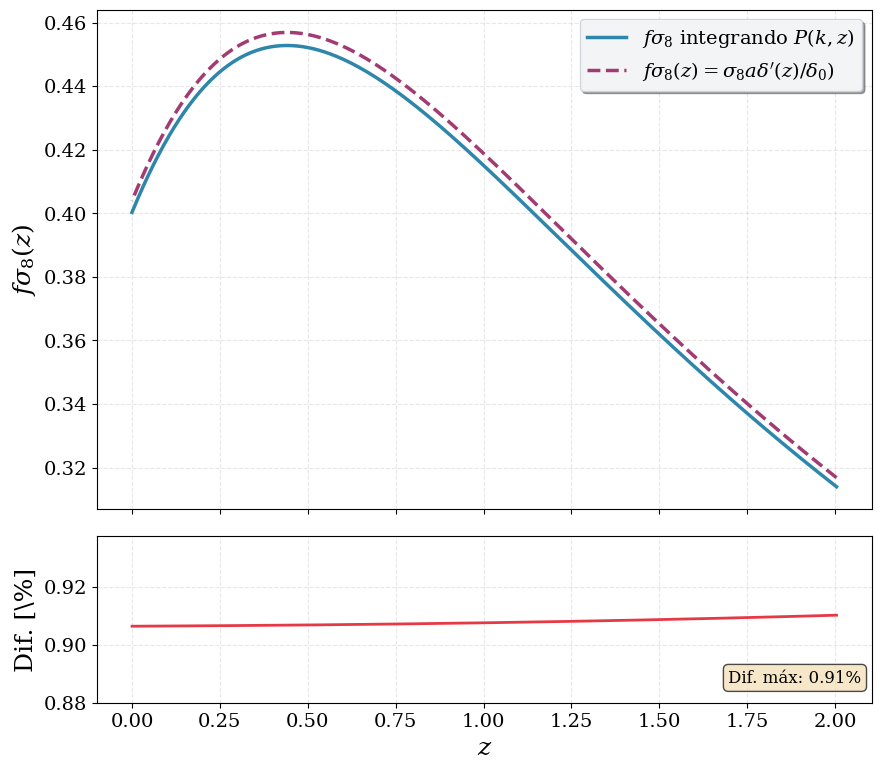

In [49]:
fsigma8_de_siempre = sigma8_class * deltas_p_LCDM_z[0,:] / deltas_LCDM_z[0,-1] * a_z
f_sigma8_LCDM = f_k_LCDM[0,:] * sigma8_lcdm
ratio_medio = np.mean(f_sigma8_LCDM/fsigma8_de_siempre)
h = solver.h
chain_rule = 1/h**3

# ===== ESTILO MEJORADO =====
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Datos y estadísticas
print(f'$h^3$ = {solver.h**3:.6f}')
print(f"Ratio medio $f\\sigma_8$ (método 1 / método 2): {ratio_medio:.6f}")

# Cálculo de diferencia porcentual
from scipy.interpolate import interp1d
z_common = np.linspace(max(z.min(), z.min()), min(z.max(), z.max()), 500)
f_interp_method1 = interp1d(z, f_sigma8_LCDM*chain_rule, kind='cubic', fill_value='extrapolate')
f_interp_method2 = interp1d(z, fsigma8_de_siempre, kind='cubic', fill_value='extrapolate')
diff_percent = np.abs(f_interp_method1(z_common) - f_interp_method2(z_common)) / f_interp_method1(z_common) * 100

max_diff = np.max(diff_percent)
mean_diff = np.mean(diff_percent)
print(f"\n{'='*60}")
print(f"DIFERENCIAS PORCENTUALES ENTRE MÉTODOS:")
print(f"{'='*60}")
print(f"  Diferencia máxima:  {max_diff:.4f}%")
print(f"  Diferencia media:   {mean_diff:.4f}%")
print(f"{'='*60}\n")

# Crear subplots con ratio de tamaños diferente
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), 
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08}, sharex=True)

# ===== SUBPLOT 1: Plot principal con colores modernos =====
ax1.plot(z, f_sigma8_LCDM*chain_rule, 
         color='#2E86AB', linewidth=2.5, linestyle='-',
         label=r'$f\sigma_8$ integrando $P(k,z)$', zorder=3)

ax1.plot(z, fsigma8_de_siempre, 
         color='#A23B72', linewidth=2.5, linestyle='--', 
         label=r'$f\sigma_8(z) = \sigma_8 a\delta^\prime(z)/\delta_0$)', zorder=2)

# Configuración de ejes con LaTeX
# ax1.set_xlabel(r'$z$', fontsize=18, fontweight='bold')
ax1.set_ylabel(r'$f\sigma_8(z)$', fontsize=18, fontweight='bold')

# Grid elegante
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Leyenda con información adicional
legend = ax1.legend(fontsize=14, frameon=True, shadow=True, 
                   fancybox=True, loc='best', framealpha=0.95)
legend.get_frame().set_facecolor('#F8F9FA')
legend.get_frame().set_edgecolor('#CED4DA')

# Aumentar tamaño de ticks
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=12)

# ===== SUBPLOT 2: Diferencia porcentual =====
ax2.plot(z_common, diff_percent, color='#E63946', linewidth=2, linestyle='-')
ax2.set_xlabel(r'$z$', fontsize=18, fontweight='bold')
ax2.set_ylabel(r'Dif. [\%]', fontsize=18)
#ylim
ax2.set_ylim(0.88, max_diff*1.03)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax2.tick_params(axis='both', which='major', labelsize=14)

# Anotación informativa en el subplot de diferencias
textstr = f'Dif. máx: {max_diff:.2f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
ax2.text(0.815, 0.20, textstr, transform=ax2.transAxes, 
         fontsize=12, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

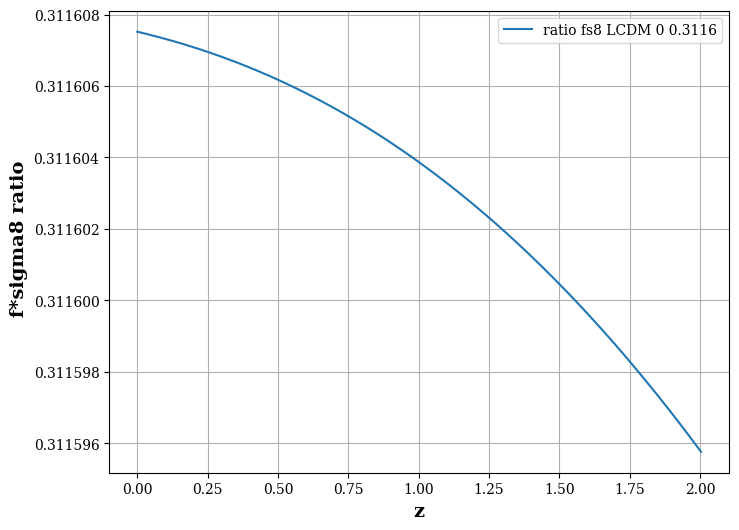

In [32]:
plt.figure(figsize=(8,6))
plt.plot(z, f_sigma8_LCDM/fsigma8_de_siempre, label=f'ratio fs8 LCDM 0 {np.mean(f_sigma8_LCDM/fsigma8_de_siempre):.4f}')
# plt.ylim(0.1, 1.05)
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel(' f*sigma8 ratio', fontsize=14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

## $f\sigma_8(z)$ integrando $f_k$

## $f\sigma_8(k,z)$ con datos

Diferencia porcentual máxima entre f*sigma_8 (eff) y f*sigma_8 (estándar): 0.1501%
Diferencia porcentual media: 0.0046%

Número de observaciones: 18
Rango de redshift observacional: z ∈ [0.02, 1.40]


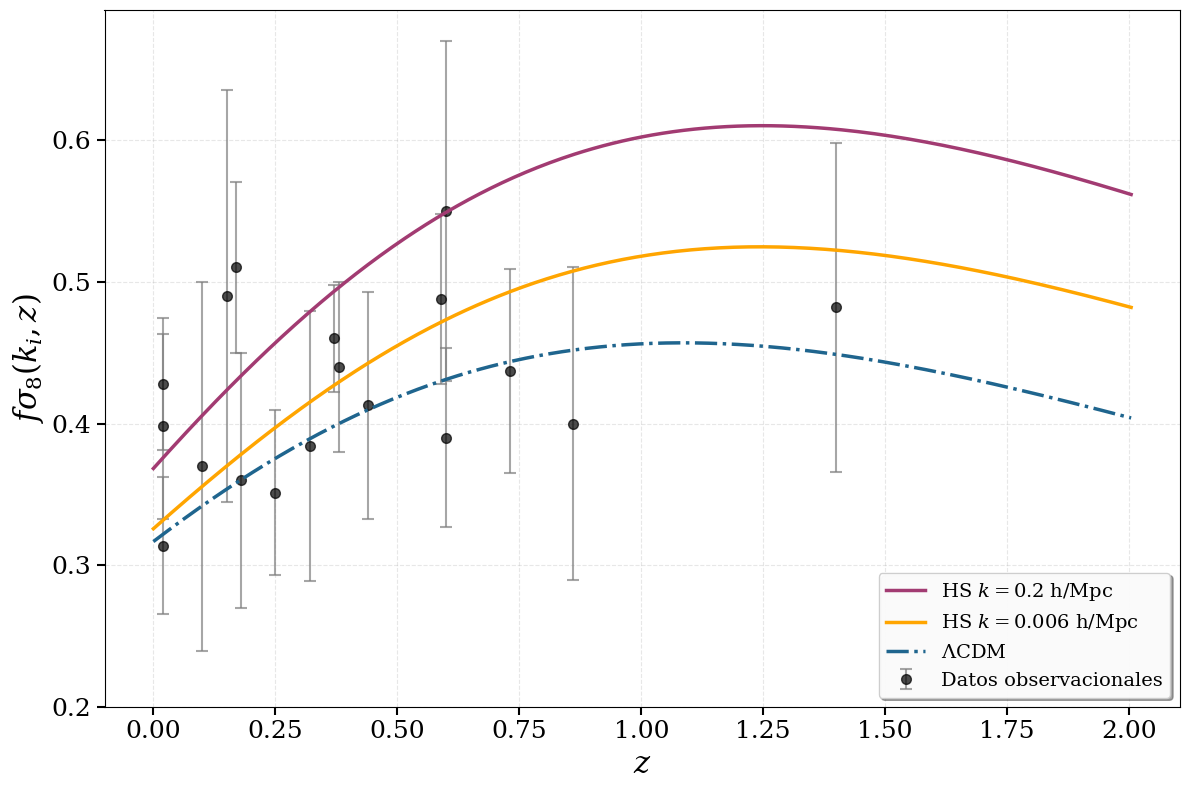

In [ ]:
# Datos observacionales de f*sigma_8(z) de la tabla
data_obs = {
    'survey': ['6dFGS|SnIa', 'SnIa|IRAS', '2MASS', 'SDSS-veloc', 'SDSS-MGS', 
               '2dFGRS', 'GAMA', 'GAMA', 'SDSS-LRG-200', 'SDSS-LRG-200',
               'BOSS-LOWZ', 'SDSS-CMASS', 'WiggleZ', 'WiggleZ', 'WiggleZ',
               'Vipers PDR-2', 'Vipers PDR-2', 'FastSound'],
    'z': [0.02, 0.02, 0.02, 0.10, 0.15, 0.17, 0.18, 0.38, 0.25, 0.37,
          0.32, 0.59, 0.44, 0.60, 0.73, 0.60, 0.86, 1.40],
    'fsigma8': [0.428, 0.398, 0.314, 0.370, 0.490, 0.510, 0.360, 0.440,
                0.3512, 0.4602, 0.384, 0.488, 0.413, 0.390, 0.437,
                0.550, 0.400, 0.482],
    'error': [0.0465, 0.065, 0.048, 0.130, 0.145, 0.060, 0.090, 0.060,
              0.0583, 0.0378, 0.095, 0.060, 0.080, 0.063, 0.072,
              0.120, 0.110, 0.116]
}

# Convertir a arrays de numpy
z_obs = np.array(data_obs['z'])
fsigma8_obs = np.array(data_obs['fsigma8'])
fsigma8_err = np.array(data_obs['error'])

# Plot mejorado de f*sigma_8 vs z con datos observacionales
fig, ax = plt.subplots(figsize=(12, 8))

# Definir colores y estilos más estéticos
colors_palette = ["#1F658E", '#A23B72', "#BC933A", '#C73E1D', '#6A994E']

# Plotear los DATOS OBSERVACIONALES primero (para que estén al fondo)
ax.errorbar(z_obs, fsigma8_obs, yerr=fsigma8_err, 
            fmt='o', markersize=7, capsize=4, capthick=1.5,
            color='black', ecolor='gray', alpha=0.7,
            label='Datos observacionales', zorder=2)

# Plotear las curvas teóricas con mejor estética
ax.plot(z_df[::-1], f_k_mg[-1,:]*sigma8_mg*chain_rule, 
        color=colors_palette[1], linewidth=2.5, linestyle='-', 
        label=r'HS $k=0.2$ h/Mpc', zorder=3)

ax.plot(z_df[::-1], f_k_mg[0,:]*sigma8_mg*chain_rule, 
        color='orange', linewidth=2.5, linestyle='-', 
        label=r'HS $k=0.006$ h/Mpc', zorder=3)

ax.plot(z_df[::-1], fsigma8_de_siempre, 
        color=colors_palette[0], linewidth=2.5, linestyle='-.', 
        label=r'$\Lambda$CDM', zorder=3)

# Calcular diferencia porcentual máxima entre los dos métodos de cálculo
from scipy.interpolate import interp1d
f_interp = interp1d(z_df[::-1], fsigma8_de_siempre, kind='linear', fill_value='extrapolate')
fsigma8_interp = f_interp(z_df[::-1])
diff_percent = np.abs((fisgma8_eff_lcdm/ratio_medio - fsigma8_interp) / fsigma8_interp) * 100
max_diff = np.max(diff_percent)
mean_diff = np.mean(diff_percent)

print(f"Diferencia porcentual máxima entre f*sigma_8 (eff) y f*sigma_8 (estándar): {max_diff:.4f}%")
print(f"Diferencia porcentual media: {mean_diff:.4f}%")
print(f"\nNúmero de observaciones: {len(z_obs)}")
print(f"Rango de redshift observacional: z ∈ [{z_obs.min():.2f}, {z_obs.max():.2f}]")

# Mejorar estética del plot
ax.set_xlabel(r'$z$', fontsize=22, fontweight='bold')
ax.set_ylabel(r'$f\sigma_8(k_i,z)$', fontsize=22, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', labelsize=14, width=1, length=3)
ax.set_yticks(np.arange(0.2, 0.7, 0.1))

# Ajustar límites del eje y para que se vean bien los datos
# ax.set_ylim(0.15, 0.65)

# Leyenda mejorada
ax.legend(fontsize=14, frameon=True, fancybox=True, shadow=True, 
          loc='best', framealpha=0.95)

# Grid elegante
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

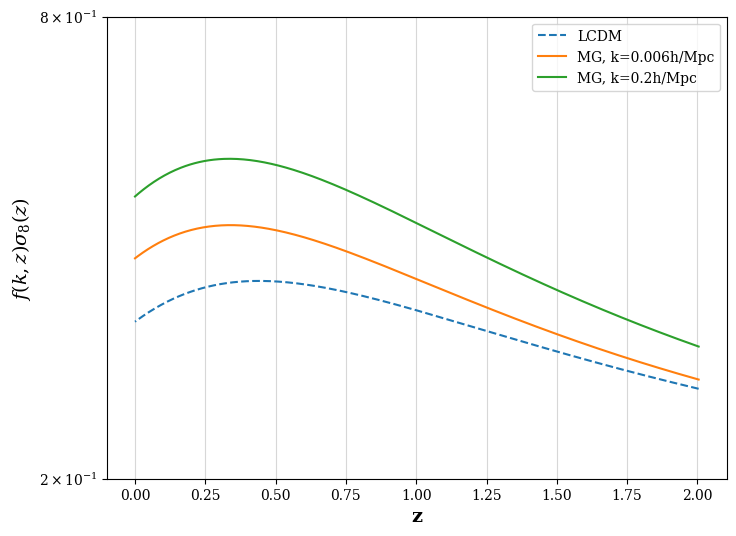

In [34]:
#compute f_k of delta_mg
sigma8_mg = df_sigma8['sigma8_MG'].values
sigma8_LCDM = df_sigma8['sigma8_LCDM'].values
deltas_mg_z = delta_mg[:, idx_z:]
deltas_p_mg_z = delta_p_mg[:, idx_z:]
ks_mg, _z_mg, f_k_mg = solver.compute_f_k_vectorized(a_vec=a_z, delta=deltas_mg_z, delta_p=deltas_p_mg_z)


plt.figure(figsize=(8,6), dpi=100)
plt.plot(z, f_k_LCDM[0,:]*sigma8_LCDM/ratio_medio, '--', label='LCDM')
# plt.plot(z, f_LCDM_clase, ':', label='f LCDM int')
plt.plot(z, f_k_mg[0,:]*sigma8_mg/ratio_medio, label ='MG, k=0.006h/Mpc')
plt.plot(z, f_k_mg[-1,:]*sigma8_mg/ratio_medio, label ='MG, k=0.2h/Mpc')
#ylims
# plt.ylim(0, 1.1)
#yticks every 0.1
plt.yticks(np.arange(0.2, .8, 0.1))
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel(f'$f(k,z) \sigma_8(z)$ ', fontsize=14, fontweight='bold')
# plt.xscale('log')
plt.yscale('symlog')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

## $f\sigma_8$ efectivo

$f\sigma _{8eff} = \frac{d \sigma _8}{dlna}$

In [35]:
df_sigma8 = pd.read_csv(f'{path}/sigma8_vs_z2.csv')
sigma8_lcdm = df_sigma8['sigma8_LCDM'].values
sigma8_MG = df_sigma8['sigma8_MG'].values
a_df, z_df = df_sigma8['a'].values, df_sigma8['z'].values
df_sigma8.head()

,a,z,sigma8_LCDM,sigma8_MG
0,0.332879,2.004094,0.103338,0.107128
1,0.334025,1.993785,0.103678,0.107519
2,0.335175,1.983512,0.104019,0.107911
3,0.336330,1.973274,0.104361,0.108304
4,0.337488,1.963071,0.104703,0.108699


In [36]:
#effective fsigma8 = dsigma8/dln a
fisgma8_eff_mg = np.gradient(sigma8_MG, np.log(a_df))
fisgma8_eff_lcdm = np.gradient(sigma8_lcdm, np.log(a_df))
fsigma8_de_siempre= deltas_p_LCDM_z[0,:] / deltas_LCDM_z[0,-1] * a_z * sigma8_class

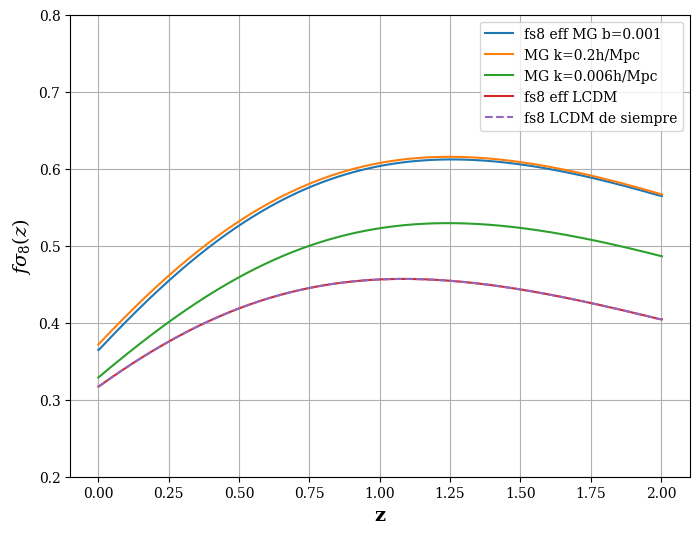

In [37]:
#plot fsigma8_eff vs z
plt.figure(figsize=(8,6))
plt.plot(z_df[::-1], fisgma8_eff_mg/ratio_medio, label='fs8 eff MG b=0.001')
plt.plot(z_df[::-1], f_k_mg[-1,:]*sigma8_mg/ratio_medio, label = 'MG k=0.2h/Mpc')
plt.plot(z_df[::-1], f_k_mg[0,:]*sigma8_mg/ratio_medio, label = 'MG k=0.006h/Mpc')
plt.plot(z_df[::-1], fisgma8_eff_lcdm/ratio_medio, label='fs8 eff LCDM')
plt.plot(z_df[::-1], fsigma8_de_siempre, '--', label='fs8 LCDM de siempre')
plt.yticks(np.arange(0.2, .8, 0.1))
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('$f\sigma_8(z)$', fontsize=14, fontweight='bold')
# plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

Diferencia porcentual máxima entre f*sigma_8 (eff) y f*sigma_8 (estándar): 0.1501%
Diferencia porcentual media: 0.0046%


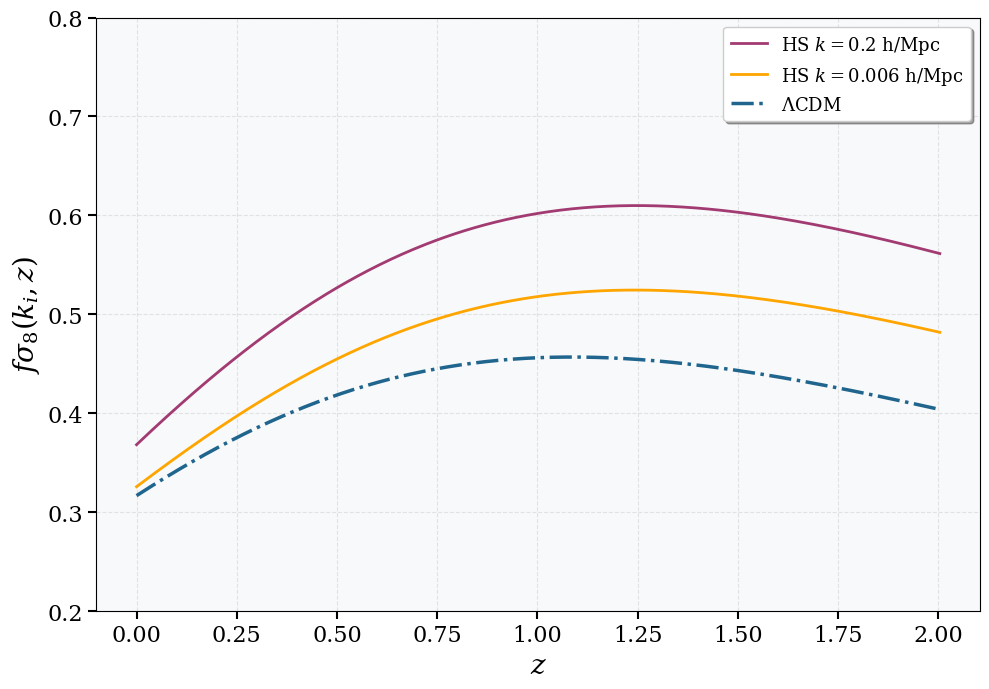

In [39]:
# Plot mejorado de f*sigma_8 vs z
fig, ax = plt.subplots(figsize=(10, 7))

# Definir colores y estilos más estéticos
colors_palette = ["#1F658E", '#A23B72', "#BC933A", '#C73E1D', '#6A994E']

# Plotear las curvas con mejor estética
# ax.plot(z_df[::-1], fisgma8_eff_mg/ratio_medio, 
#         color=colors_palette[0], linewidth=2.5, label=r'$f\sigma_8$ eff MG ($b=0.001$)')
ax.plot(z_df[::-1], f_k_mg[-1,:]*sigma8_mg*chain_rule, 
        color=colors_palette[1], linewidth=2, linestyle='-', label=r'HS $k=0.2$ h/Mpc')
ax.plot(z_df[::-1], f_k_mg[0,:]*sigma8_mg*chain_rule, 
        color='orange', linewidth=2, linestyle='-', label=r'HS $k=0.006$ h/Mpc')
	# ax.plot(z_df[::-1], fisgma8_eff_lcdm*chain_rule, 
	#         color=colors_palette[3], linewidth=2.5, label=r'$f\sigma_8$ eff $\Lambda$CDM')
ax.plot(z_df[::-1], fsigma8_de_siempre, 
        color=colors_palette[0], linewidth=2.5, linestyle='-.', 
        label=r'$\Lambda$CDM')

# Calcular diferencia porcentual máxima entre los dos métodos de cálculo
# Interpolamos fsigma8_de_siempre al mismo z que fisgma8_eff_lcdm
from scipy.interpolate import interp1d
f_interp = interp1d(z_df[::-1], fsigma8_de_siempre, kind='linear', fill_value='extrapolate')
fsigma8_interp = f_interp(z_df[::-1])
diff_percent = np.abs((fisgma8_eff_lcdm/ratio_medio - fsigma8_interp) / fsigma8_interp) * 100
max_diff = np.max(diff_percent)
mean_diff = np.mean(diff_percent)

print(f"Diferencia porcentual máxima entre f*sigma_8 (eff) y f*sigma_8 (estándar): {max_diff:.4f}%")
print(f"Diferencia porcentual media: {mean_diff:.4f}%")

# Mejorar estética del plot
ax.set_xlabel(r'$z$', fontsize=20, fontweight='bold')
ax.set_ylabel(r'$f\sigma_8(k_i,z)$', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=16, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1, length=3)
ax.set_yticks(np.arange(0.2, 0.8, 0.1))
ax.legend(fontsize=13, frameon=True, fancybox=True, shadow=True, loc='best')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## Cosas para calcular $\sigma_8 (z)$

- $\sigma_8 ^2 (z) = \frac{1}{2 \pi ^2} \int_{k_{hor}}^{k_{NL}}P(k,z)|\frac{3j_1(kR)}{kR}|^2k^2dk$
esto sale de Kamionkowski.
 $R=8h^{-1}$, pero acá $[k]=h/Mpc$, y yo tengo que meterle sin $h$ al $P_k$ (porque así entran a $\delta $) $\Rightarrow$ hay que hacer cambio de variable $ k'=kh$ 

$ \Rightarrow \sigma_8 ^2 (z) = \frac{1}{2 \pi ^2} \int_{k_{hor}'}^{k_{NL}'}P(k',z)|\frac{3j_1(k'R)}{k'R}|^2k'^2dk'/h^3 $

- $\frac{3j_1(kR)}{kR} = W(k)$ es la window function

- $P(k,z) = A_s k^{ns} |\delta_{CLASS}(k,z)|^2$